# PART A: Intrusion Detection Model

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection     import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble            import RandomForestClassifier
from sklearn.tree                import DecisionTreeClassifier
from sklearn.linear_model        import LogisticRegression
from sklearn.naive_bayes         import GaussianNB
from sklearn.preprocessing       import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics             import (accuracy_score, precision_score, recall_score,
                                         f1_score, confusion_matrix, classification_report,
                                         roc_curve, auc)
print("All libraries imported.")


All libraries imported.


## Step 1: Load the Dataset

In [8]:
print("[STEP 1] Loading ML-EdgeIIoT-dataset.csv...")
df = pd.read_csv('ML-EdgeIIoT-dataset.csv', low_memory=False)
print(f"Dataset shape: {df.shape}")
print(f"\nAttack type distribution:")
print(df['Attack_type'].value_counts())


[STEP 1] Loading ML-EdgeIIoT-dataset.csv...
Dataset shape: (157800, 63)

Attack type distribution:
Attack_type
Normal                   24301
DDoS_UDP                 14498
DDoS_ICMP                14090
Ransomware               10925
DDoS_HTTP                10561
SQL_injection            10311
Uploading                10269
DDoS_TCP                 10247
Backdoor                 10195
Vulnerability_scanner    10076
Port_Scanning            10071
XSS                      10052
Password                  9989
MITM                      1214
Fingerprinting            1001
Name: count, dtype: int64


## Step 2: Preprocessing

In [9]:
print("[STEP 2] Preprocessing...")

drop_columns = [
    "frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4",
    "arp.dst.proto_ipv4", "http.file_data", "http.request.full_uri",
    "icmp.transmit_timestamp", "http.request.uri.query", "tcp.options",
    "tcp.payload", "tcp.srcport", "tcp.dstport", "udp.port", "mqtt.msg"
]
df.drop(columns=[c for c in drop_columns if c in df.columns], inplace=True)

r0 = len(df)
df.dropna(inplace=True)
print(f"Dropped {r0 - len(df)} rows with nulls")

r0 = len(df)
df.drop_duplicates(keep='first', inplace=True)
print(f"Dropped {r0 - len(df)} duplicate rows")
print(f"Final shape: {df.shape}")


[STEP 2] Preprocessing...
Dropped 0 rows with nulls
Dropped 5604 duplicate rows
Final shape: (152196, 48)


## Step 3: Encode Categorical Variables

In [10]:
print("[STEP 3] Encoding categorical variables...")

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Attack_type' in categorical_cols:
    categorical_cols.remove('Attack_type')

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
print(f"Shape after encoding: {df_encoded.shape}")


[STEP 3] Encoding categorical variables...
Shape after encoding: (152196, 76)


## Step 4: Prepare Features and Target

In [11]:
print("[STEP 4] Preparing features and target...")

y = df_encoded['Attack_type']
X = df_encoded.drop(columns=['Attack_type'])

label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(y)
class_names   = label_encoder.classes_

print(f"Features: {X.shape[1]}  |  Classes: {len(class_names)}")
print(f"Classes: {class_names}")


[STEP 4] Preparing features and target...
Features: 75  |  Classes: 15
Classes: ['Backdoor' 'DDoS_HTTP' 'DDoS_ICMP' 'DDoS_TCP' 'DDoS_UDP' 'Fingerprinting'
 'MITM' 'Normal' 'Password' 'Port_Scanning' 'Ransomware' 'SQL_injection'
 'Uploading' 'Vulnerability_scanner' 'XSS']


## Step 5: Train-Test Split and Scaling

In [12]:
print("[STEP 5] Train-test split and scaling...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler        = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")


[STEP 5] Train-test split and scaling...
Train: (121756, 75)  |  Test: (30440, 75)


## Step 6: Model Comparison — Rationale for Random Forest
We benchmark four classifiers to experimentally prove why Random Forest is the best choice.


In [13]:
print("[STEP 6] Model comparison...")

candidate_models = {
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=300, random_state=42, n_jobs=-1),
    "Naive Bayes"        : GaussianNB(),
}

comparison_results = {}

print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Time(s)':>9}")
print("-" * 72)

for mname, clf in candidate_models.items():
    t0 = time.time()
    clf.fit(X_train_scaled, y_train)
    elapsed = time.time() - t0
    yp  = clf.predict(X_test_scaled)
    row = {
        "Accuracy" : accuracy_score(y_test, yp),
        "Precision": precision_score(y_test, yp, average='weighted', zero_division=0),
        "Recall"   : recall_score(y_test, yp, average='weighted', zero_division=0),
        "F1"       : f1_score(y_test, yp, average='weighted', zero_division=0),
        "Time (s)" : round(elapsed, 2),
    }
    comparison_results[mname] = row
    print(f"{mname:<22} {row['Accuracy']:>9.4f} {row['Precision']:>10.4f} "
          f"{row['Recall']:>8.4f} {row['F1']:>8.4f} {elapsed:>9.2f}")


[STEP 6] Model comparison...
Model                   Accuracy  Precision   Recall       F1   Time(s)
------------------------------------------------------------------------
Random Forest             0.9397     0.9400   0.9397   0.9397     16.62
Decision Tree             0.9336     0.9338   0.9336   0.9337      1.22
Logistic Regression       0.7720     0.7973   0.7720   0.7700     38.31
Naive Bayes               0.6641     0.7283   0.6641   0.6165      0.24


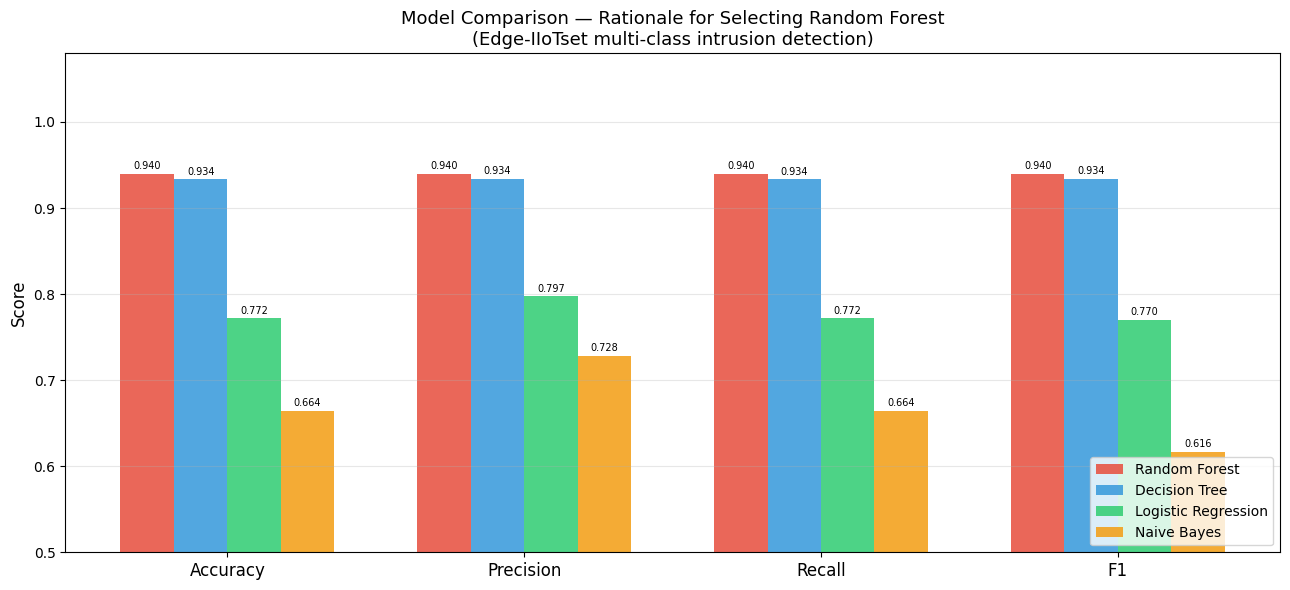

Random Forest selected: highest scores, ensemble robustness, no scaling assumption.


In [14]:
# Model comparison bar chart
metrics     = ["Accuracy", "Precision", "Recall", "F1"]
model_names = list(comparison_results.keys())
x           = np.arange(len(metrics))
bar_w       = 0.18
colors      = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (mname, color) in enumerate(zip(model_names, colors)):
    vals = [comparison_results[mname][m] for m in metrics]
    bars = ax.bar(x + i * bar_w, vals, bar_w, label=mname, color=color, alpha=0.85)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + bar_w * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.5, 1.08)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison — Rationale for Selecting Random Forest\n"
             "(Edge-IIoTset multi-class intrusion detection)", fontsize=13)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("Random Forest selected: highest scores, ensemble robustness, no scaling assumption.")


## Step 7: Train Final Random Forest with Hyperparameter Tuning

In [15]:
print("[STEP 7] Training Random Forest with hyperparameter tuning...")

rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train_scaled, y_train)

param_dist = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
}
rf_random     = RandomForestClassifier(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    rf_random, param_dist, n_iter=20, cv=5,
    scoring='f1_weighted', random_state=42, n_jobs=-1)
random_search.fit(X_train_scaled, y_train)

best_rf = random_search.best_estimator_
print(f"Best parameters: {random_search.best_params_}")


[STEP 7] Training Random Forest with hyperparameter tuning...
Best parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}


## Step 8: Evaluation and Results

In [16]:
print("[STEP 8] Evaluating model performance...")

y_pred_base = rf_base.predict(X_test_scaled)
y_pred_best = best_rf.predict(X_test_scaled)

def evaluate_model(y_true, y_pred, model_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    return acc, prec, rec, f1

evaluate_model(y_test, y_pred_base, "Random Forest (Default)")
evaluate_model(y_test, y_pred_best, "Random Forest (Tuned)")

cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='f1_weighted')
print(f"\n5-Fold CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


[STEP 8] Evaluating model performance...

Random Forest (Default):
  Accuracy:  0.9397
  Precision: 0.9400
  Recall:    0.9397
  F1-Score:  0.9397

Random Forest (Tuned):
  Accuracy:  0.9487
  Precision: 0.9506
  Recall:    0.9487
  F1-Score:  0.9487

5-Fold CV F1: 0.9470 (+/- 0.0035)


## Step 9: Confusion Matrix and Feature Importance

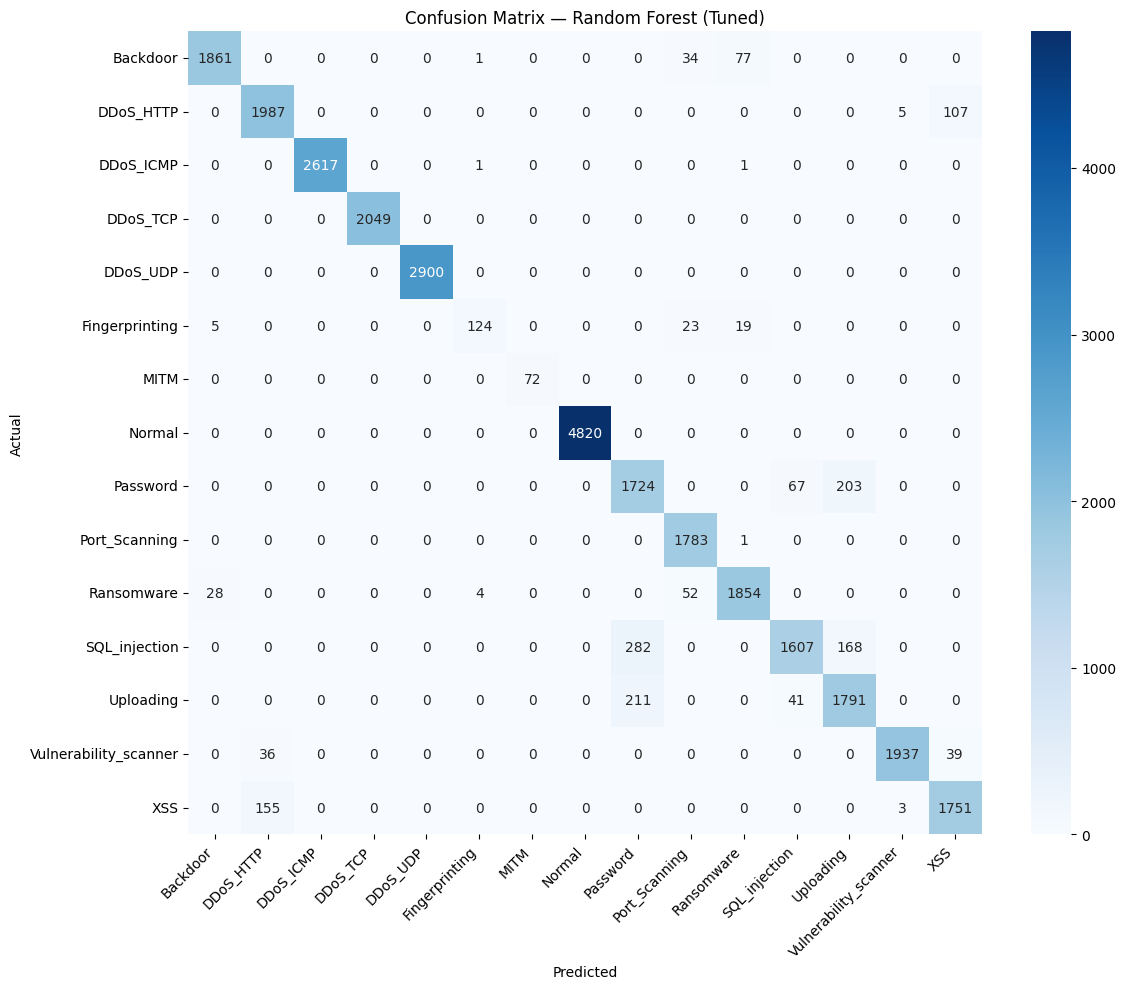

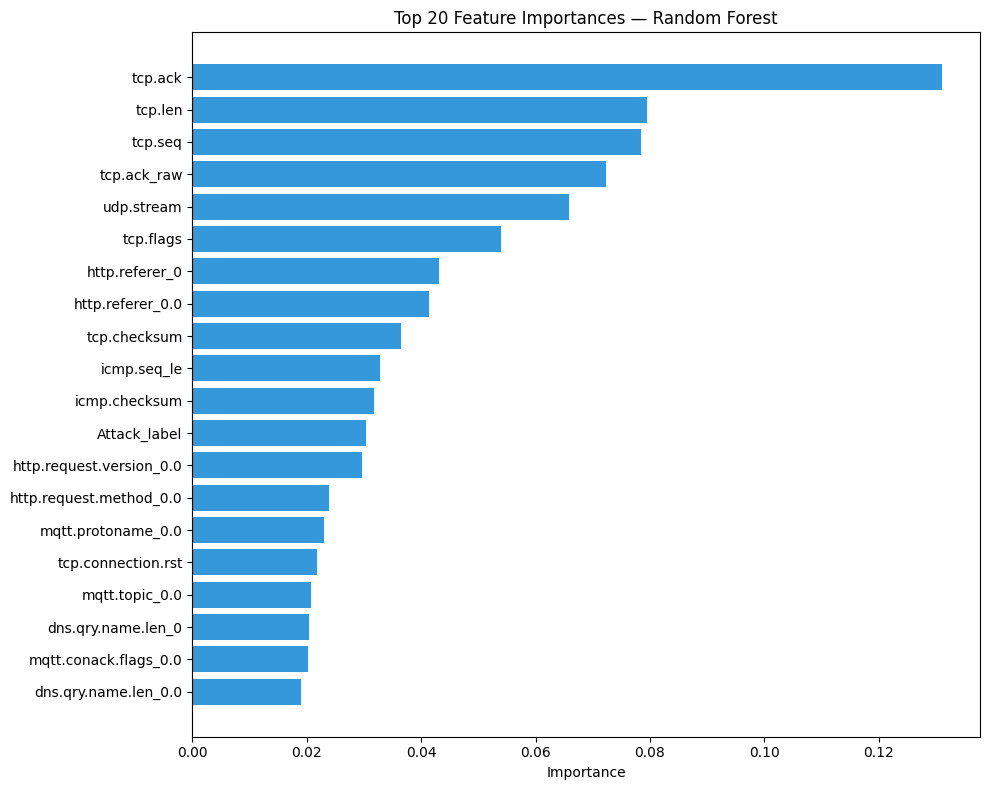

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix — Random Forest (Tuned)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Feature importance
feat_imp = pd.DataFrame({
    'feature'   : X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1], color='#3498db')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances — Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


## Step 10: ROC Curve (One-vs-Rest)

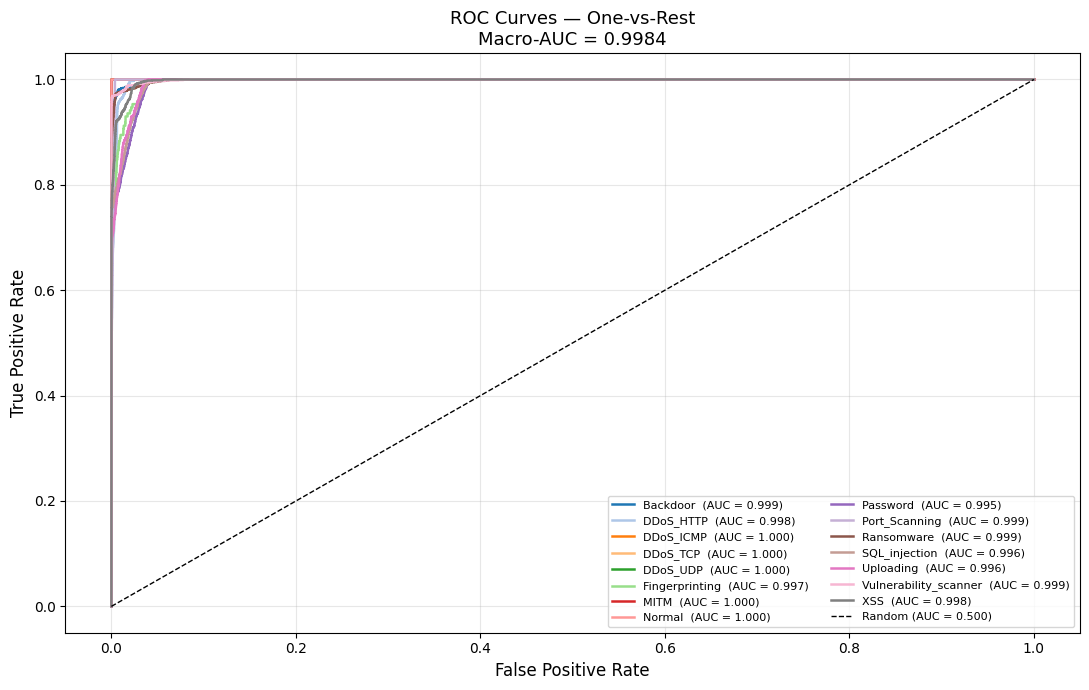

Macro-average AUC: 0.9984


In [18]:
y_test_bin  = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
y_prob_best = best_rf.predict_proba(X_test_scaled)

fig, ax = plt.subplots(figsize=(11, 7))
tab_colors = plt.cm.tab20.colors
auc_vals   = []

for i, cname in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_best[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_vals.append(roc_auc)
    ax.plot(fpr, tpr, lw=1.8, color=tab_colors[i % len(tab_colors)],
            label=f"{cname}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC Curves — One-vs-Rest\nMacro-AUC = {np.mean(auc_vals):.4f}", fontsize=13)
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Macro-average AUC: {np.mean(auc_vals):.4f}")


In [19]:
print("=" * 60)
print("PART A COMPLETED SUCCESSFULLY")
print("=" * 60)


PART A COMPLETED SUCCESSFULLY


In [20]:
import gc
del df, X, y  # after Part A finishes
gc.collect()

24418

---
# PART B: Data Poisoning Attack

Two strategies are compared:

**Strategy 1 — Random Label Flipping (baseline):** randomly picks attack samples and flips them to Normal.

**Strategy 2 — Confidence-Based Targeted Flipping (sophisticated):** trains a scout model first, then flips the attack samples the model is MOST CONFIDENT about. These are the obvious attack signatures — flipping them causes maximum detection failure with fewest label changes.


## B Step 1: Reload and Preprocess Data for Part B

In [22]:
from sklearn.utils import shuffle as sk_shuffle

print("[B-STEP 1] Loading and preprocessing data for Part B...")

df_b = pd.read_csv('ML-EdgeIIoT-dataset.csv', low_memory=False)
# After loading df
df_b = df_b.sample(frac=0.3, random_state=42).reset_index(drop=True)
print(f"Sampled shape: {df_b.shape}")
drop_columns = [
    "frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4",
    "arp.dst.proto_ipv4", "http.file_data", "http.request.full_uri",
    "icmp.transmit_timestamp", "http.request.uri.query", "tcp.options",
    "tcp.payload", "tcp.srcport", "tcp.dstport", "udp.port", "mqtt.msg"
]
df_b.drop(columns=[c for c in drop_columns if c in df_b.columns], inplace=True)
df_b.dropna(inplace=True)
df_b.drop_duplicates(keep='first', inplace=True)
df_b = sk_shuffle(df_b, random_state=42).reset_index(drop=True)

cat_cols  = [c for c in df_b.select_dtypes('object').columns if c != 'Attack_type']
df_b_enc  = pd.get_dummies(df_b, columns=cat_cols, drop_first=False)
if 'dns.qry.name' in df_b_enc.columns:
    df_b_enc.drop(columns=['dns.qry.name'], inplace=True)

y_b   = df_b_enc['Attack_type']
X_b   = df_b_enc.drop(columns=['Attack_type']).select_dtypes(exclude='object')
le_b  = LabelEncoder()
y_enc = le_b.fit_transform(y_b)

class_names    = le_b.classes_
attack_classes = [c for c in class_names if c.lower() != 'normal']
normal_class   = 'Normal'
normal_idx     = list(class_names).index(normal_class)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

scaler_b = StandardScaler()
X_tr_b   = scaler_b.fit_transform(X_train_b)
X_te_b   = scaler_b.transform(X_test_b)

print(f"Train: {X_tr_b.shape}  |  Test: {X_te_b.shape}")
print(f"Normal label index: {normal_idx}")
print(f"Classes: {class_names}")


[B-STEP 1] Loading and preprocessing data for Part B...
Sampled shape: (47340, 63)
Train: (36735, 71)  |  Test: (9184, 71)
Normal label index: 7
Classes: ['Backdoor' 'DDoS_HTTP' 'DDoS_ICMP' 'DDoS_TCP' 'DDoS_UDP' 'Fingerprinting'
 'MITM' 'Normal' 'Password' 'Port_Scanning' 'Ransomware' 'SQL_injection'
 'Uploading' 'Vulnerability_scanner' 'XSS']


## B Step 2: Train Scout Model for Confidence Scores

In [23]:
print("[B-STEP 2] Training scout model for confidence scores...")
scout       = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=0)
scout.fit(X_tr_b, y_train_b)
train_proba = scout.predict_proba(X_tr_b)
print(f"Scout trained — confidence scores shape: {train_proba.shape}")


[B-STEP 2] Training scout model for confidence scores...
Scout trained — confidence scores shape: (36735, 15)


## B Step 3: Define Poisoning Functions

In [24]:
def sophisticated_label_poisoning(y_true, poison_pct, normal_idx, confidence_scores):
    """
    Flip the attack samples the model is MOST CONFIDENT about.
    Sorts all attack samples by descending prediction confidence,
    then flips the top N to Normal. More dangerous than random because:
    - Removes the most obvious attack signatures from training.
    - Model learns to classify clear attacks as Normal.
    - Maximum detection failure per label changed.
    """
    y_p        = y_true.copy()
    attack_idx = np.where(y_true != normal_idx)[0]
    n_flip     = min(int(len(y_true) * poison_pct / 100), len(attack_idx))
    if n_flip == 0:
        return y_p, np.array([], dtype=int)
    conf         = confidence_scores[attack_idx].max(axis=1)
    sorted_order = np.argsort(-conf)
    to_flip      = attack_idx[sorted_order[:n_flip]]
    y_p[to_flip] = normal_idx
    return y_p, to_flip


def random_label_poisoning(y_true, poison_pct, normal_idx):
    """
    Randomly flip (poison_pct % of total training samples) attack labels to Normal.
    Baseline comparison strategy.
    """
    y_p        = y_true.copy()
    attack_idx = np.where(y_true != normal_idx)[0]
    n_flip     = min(int(len(y_true) * poison_pct / 100), len(attack_idx))
    if n_flip == 0:
        return y_p, np.array([], dtype=int)
    to_flip      = np.random.choice(attack_idx, n_flip, replace=False)
    y_p[to_flip] = normal_idx
    return y_p, to_flip


print("Poisoning functions defined.")
print("  Sophisticated: flips highest-confidence attack samples first")
print("  Random:        flips randomly chosen attack samples (baseline)")


Poisoning functions defined.
  Sophisticated: flips highest-confidence attack samples first
  Random:        flips randomly chosen attack samples (baseline)


## B Step 4: Experiment Loop — Train Each Model Once

In [29]:
np.random.seed(42)

poisoning_percentages = [0, 1, 2, 5, 10, 15, 20, 30, 40, 50]
results_soph = []
results_rand = []

def get_metrics(y_true, y_pred, norm_idx, n_flipped, pct, y_pred_stored):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    atk = (y_true != norm_idx)
    fnr = float(np.mean(y_pred[atk] == norm_idx)) if atk.sum() > 0 else 0.0
    return dict(pct=pct, acc=acc, f1=f1, recall=rec, fnr=fnr,
                n_flipped=n_flipped,
                y_pred=y_pred_stored)   # ← store predictions, not model

print(f"{'%':>4}  {'Sophisticated':^50}  {'Random':^50}")
print(f"{'':>4}  {'Acc':>7} {'F1':>7} {'Recall':>7} {'FNR':>7} {'#Flip':>7}  "
      f"{'Acc':>7} {'F1':>7} {'Recall':>7} {'FNR':>7} {'#Flip':>7}")
print("-" * 110)

for pct in poisoning_percentages:
    import gc

    y_pois_s, flipped_s = sophisticated_label_poisoning(y_train_b, pct, normal_idx, train_proba)
    y_pois_r, flipped_r = random_label_poisoning(y_train_b, pct, normal_idx)

    rf_s = RandomForestClassifier(n_estimators=40, random_state=42, n_jobs=-1)
    rf_s.fit(X_tr_b, y_pois_s)
    yp_s = rf_s.predict(X_te_b)
    ms   = get_metrics(y_test_b, yp_s, normal_idx, len(flipped_s), pct, yp_s)
    del rf_s
    gc.collect()

    rf_r = RandomForestClassifier(n_estimators=40, random_state=42, n_jobs=-1)
    rf_r.fit(X_tr_b, y_pois_r)
    yp_r = rf_r.predict(X_te_b)
    mr   = get_metrics(y_test_b, yp_r, normal_idx, len(flipped_r), pct, yp_r)
    del rf_r
    gc.collect()

    results_soph.append(ms)
    results_rand.append(mr)

    print(f"{pct:>3}%  "
          f"{ms['acc']:>7.4f} {ms['f1']:>7.4f} {ms['recall']:>7.4f} "
          f"{ms['fnr']:>7.4f} {ms['n_flipped']:>7}  "
          f"{mr['acc']:>7.4f} {mr['f1']:>7.4f} {mr['recall']:>7.4f} "
          f"{mr['fnr']:>7.4f} {mr['n_flipped']:>7}")

print("\nAll experiments complete.")

   %                    Sophisticated                                           Random                      
          Acc      F1  Recall     FNR   #Flip      Acc      F1  Recall     FNR   #Flip
--------------------------------------------------------------------------------------------------------------
  0%   0.9362  0.9361  0.9362  0.0000       0   0.9362  0.9361  0.9362  0.0000       0
  1%   0.9341  0.9340  0.9341  0.0026     367   0.9350  0.9348  0.9350  0.0019     367
  2%   0.9324  0.9322  0.9324  0.0052     734   0.9335  0.9333  0.9335  0.0038     734
  5%   0.9244  0.9242  0.9244  0.0135    1836   0.9253  0.9248  0.9253  0.0146    1836
 10%   0.9045  0.9045  0.9045  0.0390    3673   0.8997  0.8997  0.8997  0.0483    3673
 15%   0.8703  0.8722  0.8703  0.0807    5510   0.8790  0.8809  0.8790  0.0807    5510
 20%   0.8178  0.8246  0.8178  0.1420    7347   0.8416  0.8476  0.8416  0.1288    7347
 30%   0.6753  0.6972  0.6753  0.3123   11020   0.7255  0.7494  0.7255  0.2818   110

## B Step 5: Visualise — 4-Panel Degradation Chart

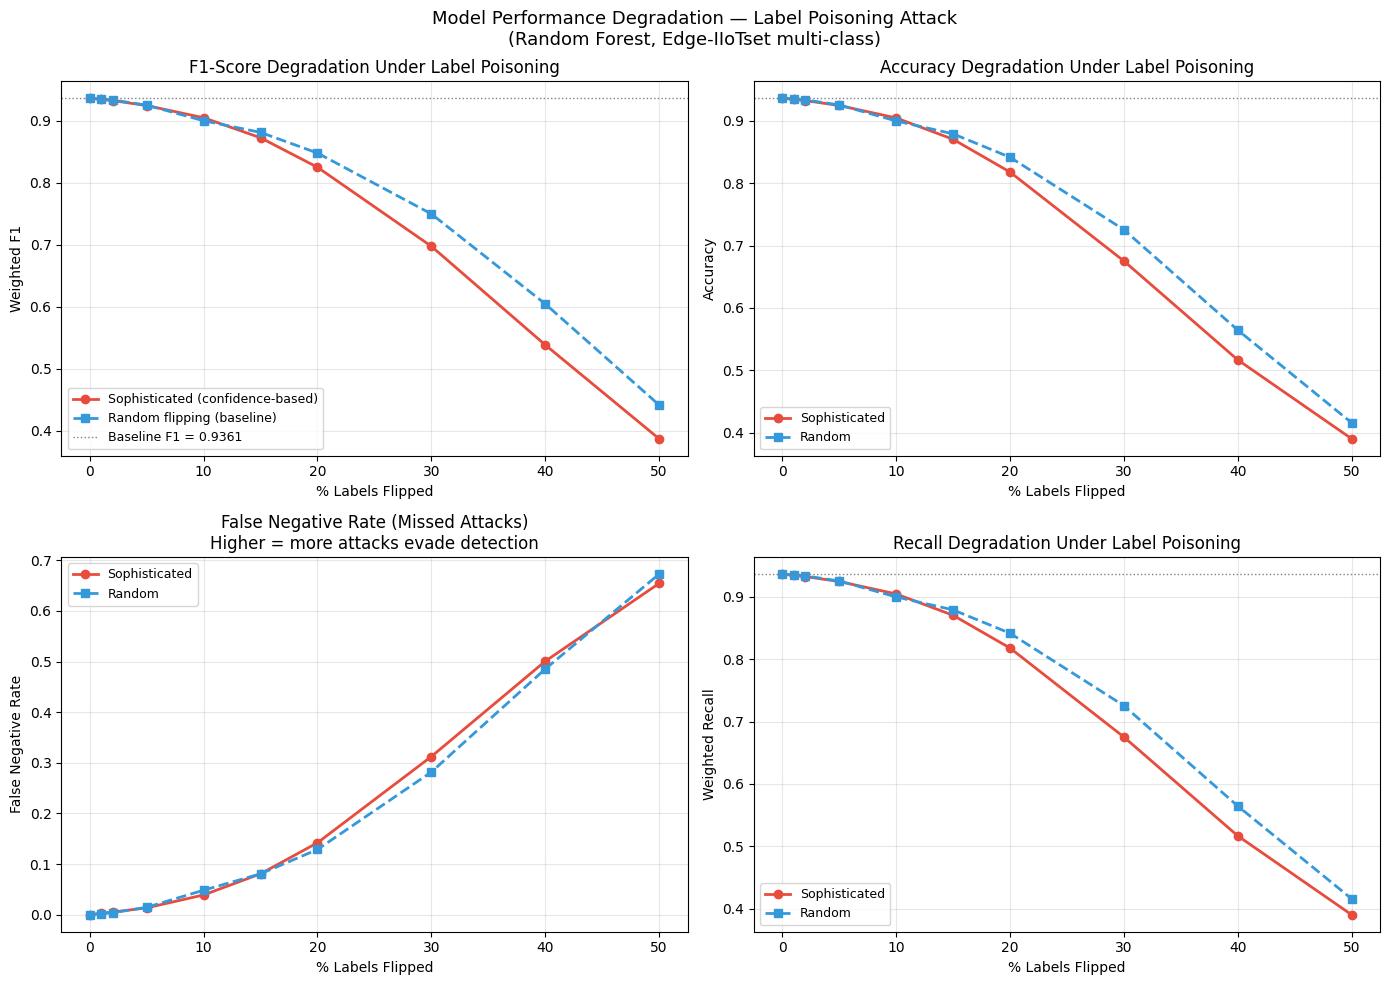

Saved: poisoning_degradation.png


In [30]:
pcts = [r['pct'] for r in results_soph]

def extr(res, key):
    return [r[key] for r in res]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# F1
ax = axes[0, 0]
ax.plot(pcts, extr(results_soph, 'f1'), 'o-', color='#e74c3c', lw=2,
        label='Sophisticated (confidence-based)')
ax.plot(pcts, extr(results_rand, 'f1'), 's--', color='#3498db', lw=2,
        label='Random flipping (baseline)')
ax.axhline(results_soph[0]['f1'], color='gray', ls=':', lw=1,
           label=f"Baseline F1 = {results_soph[0]['f1']:.4f}")
ax.set_title('F1-Score Degradation Under Label Poisoning')
ax.set_xlabel('% Labels Flipped'); ax.set_ylabel('Weighted F1')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Accuracy
ax = axes[0, 1]
ax.plot(pcts, extr(results_soph, 'acc'), 'o-', color='#e74c3c', lw=2, label='Sophisticated')
ax.plot(pcts, extr(results_rand, 'acc'), 's--', color='#3498db', lw=2, label='Random')
ax.axhline(results_soph[0]['acc'], color='gray', ls=':', lw=1)
ax.set_title('Accuracy Degradation Under Label Poisoning')
ax.set_xlabel('% Labels Flipped'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# FNR — key metric
ax = axes[1, 0]
ax.plot(pcts, extr(results_soph, 'fnr'), 'o-', color='#e74c3c', lw=2, label='Sophisticated')
ax.plot(pcts, extr(results_rand, 'fnr'), 's--', color='#3498db', lw=2, label='Random')
ax.set_title('False Negative Rate (Missed Attacks)\nHigher = more attacks evade detection')
ax.set_xlabel('% Labels Flipped'); ax.set_ylabel('False Negative Rate')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Recall
ax = axes[1, 1]
ax.plot(pcts, extr(results_soph, 'recall'), 'o-', color='#e74c3c', lw=2, label='Sophisticated')
ax.plot(pcts, extr(results_rand, 'recall'), 's--', color='#3498db', lw=2, label='Random')
ax.axhline(results_soph[0]['recall'], color='gray', ls=':', lw=1)
ax.set_title('Recall Degradation Under Label Poisoning')
ax.set_xlabel('% Labels Flipped'); ax.set_ylabel('Weighted Recall')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Model Performance Degradation — Label Poisoning Attack\n'
             '(Random Forest, Edge-IIoTset multi-class)', fontsize=13)
plt.tight_layout()
plt.savefig('poisoning_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: poisoning_degradation.png")


## B Step 6: FNR Efficiency Plot

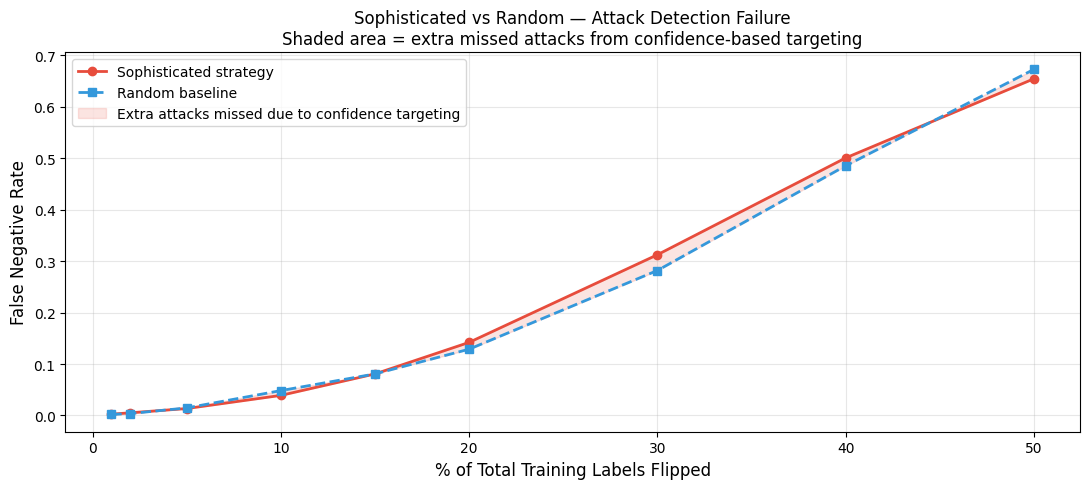

Saved: strategy_efficiency.png


In [31]:
fig, ax = plt.subplots(figsize=(11, 5))

x_pcts = pcts[1:]
fnr_s  = extr(results_soph, 'fnr')[1:]
fnr_r  = extr(results_rand, 'fnr')[1:]

ax.plot(x_pcts, fnr_s, 'o-', color='#e74c3c', lw=2, label='Sophisticated strategy')
ax.plot(x_pcts, fnr_r, 's--', color='#3498db', lw=2, label='Random baseline')
ax.fill_between(x_pcts, fnr_r, fnr_s, alpha=0.15, color='#e74c3c',
                label='Extra attacks missed due to confidence targeting')

ax.set_xlabel('% of Total Training Labels Flipped', fontsize=12)
ax.set_ylabel('False Negative Rate', fontsize=12)
ax.set_title('Sophisticated vs Random — Attack Detection Failure\n'
             'Shaded area = extra missed attacks from confidence-based targeting', fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('strategy_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: strategy_efficiency.png")


## B Step 7: Confusion Matrices at 0%, 10%, 30% Poisoning

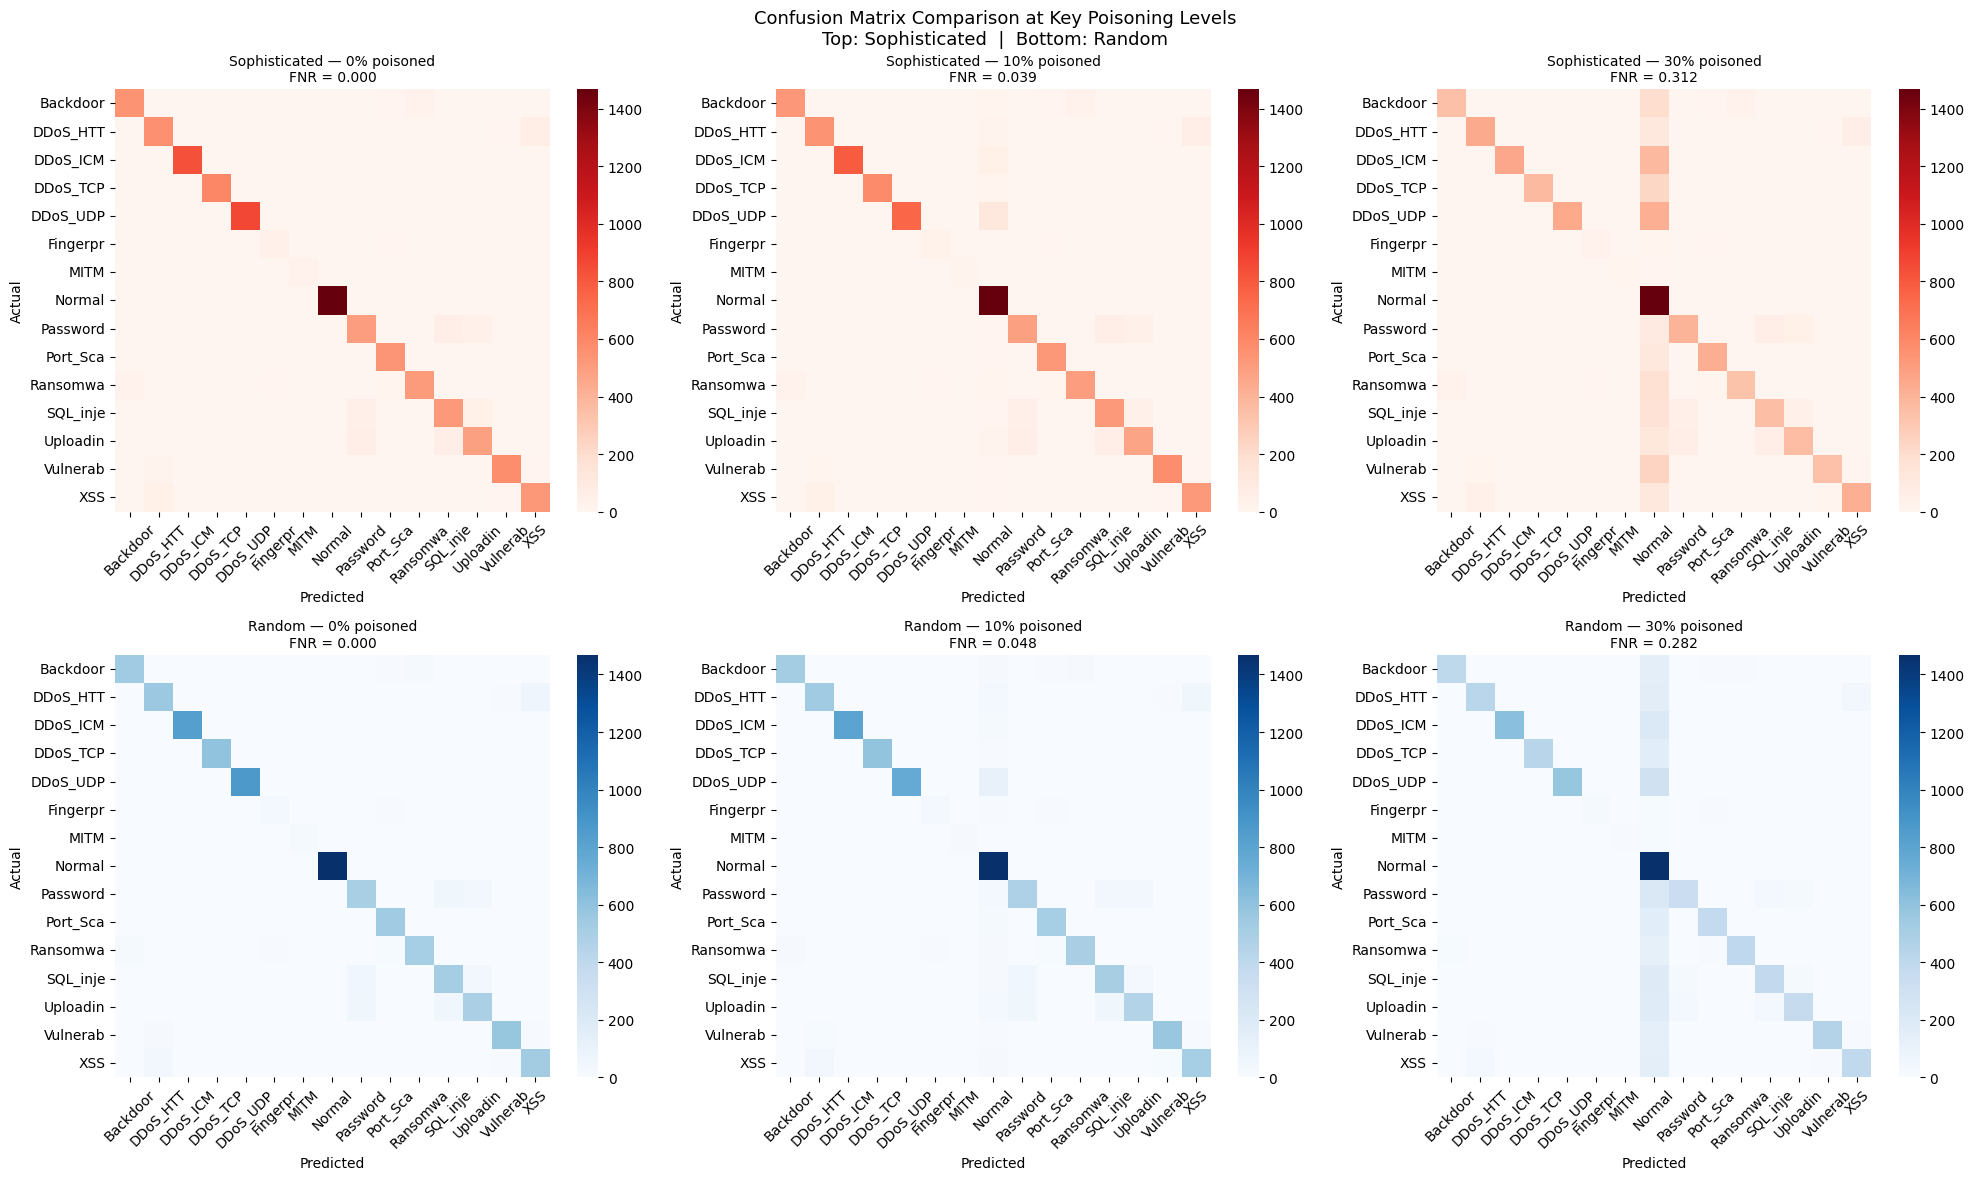

Saved: confusion_matrices_poisoning.png


In [32]:
critical_levels = [0, 10, 30]
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
short_labels = [c[:8] for c in class_names]

for col, pct in enumerate(critical_levels):
    result_s = next(r for r in results_soph if r['pct'] == pct)
    result_r = next(r for r in results_rand  if r['pct'] == pct)

    # ← use stored predictions instead of model.predict()
    yp_s = result_s['y_pred']
    yp_r = result_r['y_pred']

    cm_s = confusion_matrix(y_test_b, yp_s)
    sns.heatmap(cm_s, annot=False, cmap='Reds', ax=axes[0, col],
                xticklabels=short_labels, yticklabels=short_labels)
    axes[0, col].set_title(f'Sophisticated — {pct}% poisoned\nFNR = {result_s["fnr"]:.3f}', fontsize=10)
    axes[0, col].set_xlabel('Predicted'); axes[0, col].set_ylabel('Actual')
    axes[0, col].tick_params(axis='x', rotation=45)

    cm_r = confusion_matrix(y_test_b, yp_r)
    sns.heatmap(cm_r, annot=False, cmap='Blues', ax=axes[1, col],
                xticklabels=short_labels, yticklabels=short_labels)
    axes[1, col].set_title(f'Random — {pct}% poisoned\nFNR = {result_r["fnr"]:.3f}', fontsize=10)
    axes[1, col].set_xlabel('Predicted'); axes[1, col].set_ylabel('Actual')
    axes[1, col].tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrix Comparison at Key Poisoning Levels\n'
             'Top: Sophisticated  |  Bottom: Random', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices_poisoning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices_poisoning.png")

## B Step 8: Summary Table and Key Findings

In [33]:
print("=" * 110)
print("PART B — SUMMARY TABLE")
print("=" * 110)
print(f"{'Flip%':>6}  {'SophAcc':>8} {'SophF1':>7} {'SophFNR':>8} {'SophFlip':>9}  "
      f"{'RandAcc':>8} {'RandF1':>7} {'RandFNR':>8} {'RandFlip':>9}  {'FNR_Adv':>8}")
print("-" * 110)

for ms, mr in zip(results_soph, results_rand):
    adv = ms['fnr'] - mr['fnr']
    print(f"{ms['pct']:>5}%  "
          f"{ms['acc']:>8.4f} {ms['f1']:>7.4f} {ms['fnr']:>8.4f} {ms['n_flipped']:>9}  "
          f"{mr['acc']:>8.4f} {mr['f1']:>7.4f} {mr['fnr']:>8.4f} {mr['n_flipped']:>9}  "
          f"{adv:>+8.4f}")

print("=" * 110)
print()

fnr_10_s = next(r for r in results_soph if r['pct'] == 10)['fnr']
fnr_10_r = next(r for r in results_rand  if r['pct'] == 10)['fnr']
fnr_30_s = next(r for r in results_soph if r['pct'] == 30)['fnr']
fnr_30_r = next(r for r in results_rand  if r['pct'] == 30)['fnr']

print("KEY FINDINGS:")
print(f"  Baseline (0%)  — F1: {results_soph[0]['f1']:.4f}  FNR: {results_soph[0]['fnr']:.4f}")
print(f"  10% poisoned   — Sophisticated FNR: {fnr_10_s:.4f}  vs  Random FNR: {fnr_10_r:.4f}")
print(f"  30% poisoned   — Sophisticated FNR: {fnr_30_s:.4f}  vs  Random FNR: {fnr_30_r:.4f}")
print()
print("  Sophisticated strategy causes higher FNR with same label count,")
print("  proving confidence-targeted poisoning is more efficient and dangerous.")
print("=" * 110)


PART B — SUMMARY TABLE
 Flip%   SophAcc  SophF1  SophFNR  SophFlip   RandAcc  RandF1  RandFNR  RandFlip   FNR_Adv
--------------------------------------------------------------------------------------------------------------
    0%    0.9362  0.9361   0.0000         0    0.9362  0.9361   0.0000         0   +0.0000
    1%    0.9341  0.9340   0.0026       367    0.9350  0.9348   0.0019       367   +0.0006
    2%    0.9324  0.9322   0.0052       734    0.9335  0.9333   0.0038       734   +0.0014
    5%    0.9244  0.9242   0.0135      1836    0.9253  0.9248   0.0146      1836   -0.0012
   10%    0.9045  0.9045   0.0390      3673    0.8997  0.8997   0.0483      3673   -0.0093
   15%    0.8703  0.8722   0.0807      5510    0.8790  0.8809   0.0807      5510   +0.0000
   20%    0.8178  0.8246   0.1420      7347    0.8416  0.8476   0.1288      7347   +0.0132
   30%    0.6753  0.6972   0.3123     11020    0.7255  0.7494   0.2818     11020   +0.0306
   40%    0.5169  0.5382   0.5005     14694    

In [34]:
print("SOPHISTICATED STRATEGY ADVANTAGE:")
print("-" * 50)
print("1. Scout model identifies the attack samples the classifier is most certain about")
print("2. These highest-confidence samples are flipped to Normal first")
print("3. Model learns that its most obvious attack patterns are actually benign traffic")
print("4. Fewer label changes needed to cause the same detection failure rate")
print("5. Harder to detect because high-confidence samples look statistically clean")
print()
print("SECURITY IMPLICATIONS:")
print("-" * 50)
print("  Even 5-10% label poisoning can severely degrade model performance")
print("  Confidence-targeted attacks maximise impact with minimal label changes")
print("  Organisations need data validation, anomaly detection, and regular retraining")
print()
print("=" * 60)
print("PART B COMPLETED SUCCESSFULLY")
print("=" * 60)


SOPHISTICATED STRATEGY ADVANTAGE:
--------------------------------------------------
1. Scout model identifies the attack samples the classifier is most certain about
2. These highest-confidence samples are flipped to Normal first
3. Model learns that its most obvious attack patterns are actually benign traffic
4. Fewer label changes needed to cause the same detection failure rate
5. Harder to detect because high-confidence samples look statistically clean

SECURITY IMPLICATIONS:
--------------------------------------------------
  Even 5-10% label poisoning can severely degrade model performance
  Confidence-targeted attacks maximise impact with minimal label changes
  Organisations need data validation, anomaly detection, and regular retraining

PART B COMPLETED SUCCESSFULLY


---
# PART C: Autonomous Agent Block Diagram


PART C: AUTONOMOUS AGENT BLOCK DIAGRAM


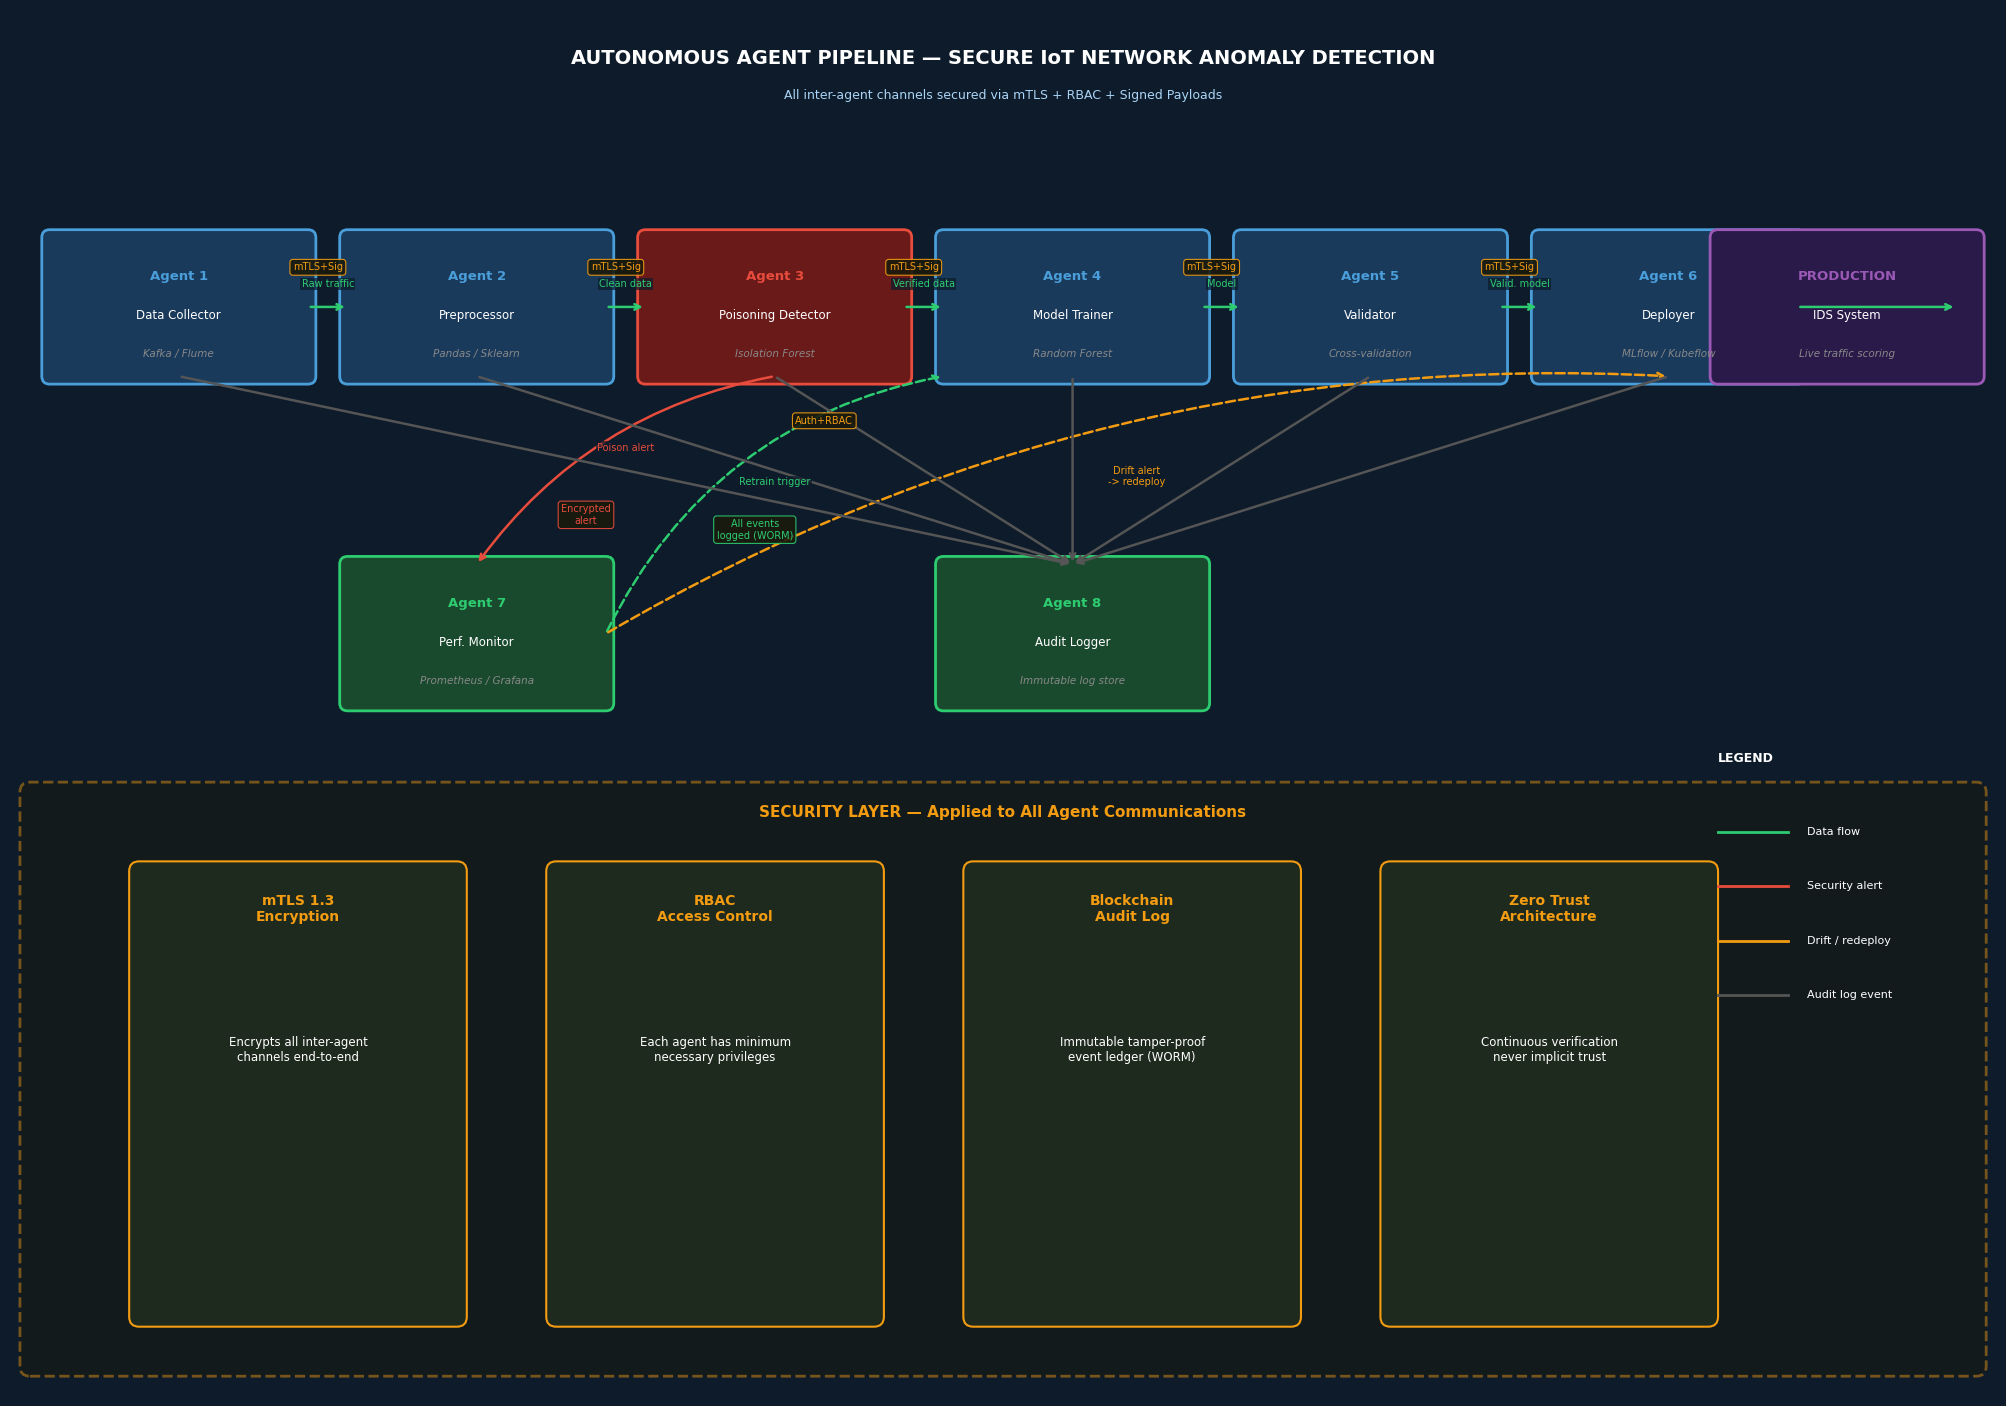

Saved: autonomous_agent_diagram.png / .pdf
PART C COMPLETED


In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Rectangle
import numpy as np

print("=" * 70)
print("PART C: AUTONOMOUS AGENT BLOCK DIAGRAM")
print("=" * 70)

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_xlim(0, 20); ax.set_ylim(0, 14)
ax.set_facecolor('#0d1b2a'); fig.patch.set_facecolor('#0d1b2a')
ax.axis('off')

BG_AGENT    = '#1a3a5c';  EDGE_AGENT    = '#4a9eda'
BG_SECURE   = '#6b1a1a';  EDGE_SECURE   = '#e74c3c'
BG_MONITOR  = '#1a4a2e';  EDGE_MONITOR  = '#2ecc71'
BG_PROD     = '#2a1a4a';  EDGE_PROD     = '#9b59b6'
EDGE_SEC_LAY = '#f39c12'

def draw_agent(x, y, w, h, title, subtitle, tech, bg=BG_AGENT, edge=EDGE_AGENT):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                         facecolor=bg, edgecolor=edge, linewidth=2, zorder=3)
    ax.add_patch(box)
    ax.text(x+w/2, y+h*0.72, title,   ha='center', va='center', fontsize=9.5,
            fontweight='bold', color=edge, zorder=4)
    ax.text(x+w/2, y+h*0.44, subtitle, ha='center', va='center', fontsize=8.5,
            color='white', zorder=4)
    ax.text(x+w/2, y+h*0.16, tech,    ha='center', va='center', fontsize=7.5,
            color='#888888', style='italic', zorder=4)

def arrow(x1, y1, x2, y2, label='', color='#2ecc71', rad=0.0, ls='-'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8,
                                connectionstyle=f'arc3,rad={rad}',
                                linestyle=ls), zorder=5)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my+0.2, label, ha='center', fontsize=7, color=color, zorder=6,
                bbox=dict(fc='#0d1b2a', ec='none', alpha=0.7, pad=1))

def badge(x, y, text, color='#f39c12'):
    ax.text(x, y, text, ha='center', va='center', fontsize=7, color=color, zorder=7,
            bbox=dict(fc='#1a1a0d', ec=color, linewidth=0.8,
                      boxstyle='round,pad=0.3', alpha=0.9))

ax.text(10, 13.45, 'AUTONOMOUS AGENT PIPELINE — SECURE IoT NETWORK ANOMALY DETECTION',
        ha='center', fontsize=14, fontweight='bold', color='white', zorder=5)
ax.text(10, 13.1,  'All inter-agent channels secured via mTLS + RBAC + Signed Payloads',
        ha='center', fontsize=9, color='#aad4f5', zorder=5)

AW, AH, Y_TOP = 2.6, 1.4, 10.3
draw_agent( 0.4, Y_TOP, AW, AH, 'Agent 1', 'Data Collector',     'Kafka / Flume')
draw_agent( 3.4, Y_TOP, AW, AH, 'Agent 2', 'Preprocessor',       'Pandas / Sklearn')
draw_agent( 6.4, Y_TOP, AW, AH, 'Agent 3', 'Poisoning Detector', 'Isolation Forest',
            bg=BG_SECURE, edge=EDGE_SECURE)
draw_agent( 9.4, Y_TOP, AW, AH, 'Agent 4', 'Model Trainer',      'Random Forest')
draw_agent(12.4, Y_TOP, AW, AH, 'Agent 5', 'Validator',          'Cross-validation')
draw_agent(15.4, Y_TOP, AW, AH, 'Agent 6', 'Deployer',           'MLflow / Kubeflow')
draw_agent(17.2, Y_TOP, AW, AH, 'PRODUCTION', 'IDS System',      'Live traffic scoring',
            bg=BG_PROD, edge=EDGE_PROD)

Y_MID = 7.0
draw_agent(3.4, Y_MID, AW, AH, 'Agent 7', 'Perf. Monitor', 'Prometheus / Grafana',
           bg=BG_MONITOR, edge=EDGE_MONITOR)
draw_agent(9.4, Y_MID, AW, AH, 'Agent 8', 'Audit Logger',  'Immutable log store',
           bg=BG_MONITOR, edge=EDGE_MONITOR)

arrow( 3.0, Y_TOP+0.7,  3.4, Y_TOP+0.7, 'Raw traffic',   '#2ecc71')
arrow( 6.0, Y_TOP+0.7,  6.4, Y_TOP+0.7, 'Clean data',    '#2ecc71')
arrow( 9.0, Y_TOP+0.7,  9.4, Y_TOP+0.7, 'Verified data', '#2ecc71')
arrow(12.0, Y_TOP+0.7, 12.4, Y_TOP+0.7, 'Model',         '#2ecc71')
arrow(15.0, Y_TOP+0.7, 15.4, Y_TOP+0.7, 'Valid. model',  '#2ecc71')
arrow(18.0, Y_TOP+0.7, 19.6, Y_TOP+0.7, '',              '#2ecc71')

for bx in [3.1, 6.1, 9.1, 12.1, 15.1]:
    badge(bx, Y_TOP+1.1, 'mTLS+Sig')

arrow(7.7, Y_TOP, 4.7, Y_MID+AH, 'Poison alert', '#e74c3c', rad=0.2)
badge(5.8, Y_MID+AH+0.5, 'Encrypted\nalert', '#e74c3c')
arrow(6.0, Y_MID+0.7, 9.4, Y_TOP, 'Retrain trigger', '#2ecc71', rad=-0.25, ls='--')
badge(8.2, Y_TOP-0.45, 'Auth+RBAC')
arrow(6.0, Y_MID+0.7, 15.4+AW/2, Y_TOP, 'Drift alert\n-> redeploy', '#f39c12', rad=-0.15, ls='--')

for ax_x in [1.7, 4.7, 7.7, 10.7, 13.7, 16.7]:
    arrow(ax_x, Y_TOP, 10.7, Y_MID+AH, '', '#555555')
badge(7.5, Y_MID+AH+0.35, 'All events\nlogged (WORM)', '#2ecc71')

sec_layer = FancyBboxPatch((0.2, 0.3), 19.6, 5.8, boxstyle="round,pad=0.1",
                            facecolor='#1a1a0d', edgecolor=EDGE_SEC_LAY,
                            linewidth=2, linestyle='--', zorder=1, alpha=0.45)
ax.add_patch(sec_layer)
ax.text(10, 5.85, 'SECURITY LAYER — Applied to All Agent Communications',
        ha='center', fontsize=11, fontweight='bold', color=EDGE_SEC_LAY, zorder=3)

for label, desc, cx in [
    ('mTLS 1.3\nEncryption',     'Encrypts all inter-agent\nchannels end-to-end',  1.3),
    ('RBAC\nAccess Control',     'Each agent has minimum\nnecessary privileges',    5.5),
    ('Blockchain\nAudit Log',    'Immutable tamper-proof\nevent ledger (WORM)',      9.7),
    ('Zero Trust\nArchitecture', 'Continuous verification\nnever implicit trust',  13.9),
]:
    box = FancyBboxPatch((cx, 0.8), 3.2, 4.5, boxstyle="round,pad=0.1",
                          facecolor='#1e2a1e', edgecolor=EDGE_SEC_LAY,
                          linewidth=1.5, zorder=2)
    ax.add_patch(box)
    ax.text(cx+1.6, 4.8, label, ha='center', fontsize=10, fontweight='bold',
            color=EDGE_SEC_LAY, zorder=3)
    ax.text(cx+1.6, 3.5, desc, ha='center', va='center', fontsize=8.5,
            color='white', zorder=3)

lx, ly = 17.2, 3.8
ax.text(lx, ly+2.6, 'LEGEND', fontsize=9, fontweight='bold', color='white')
for i, (color, lbl) in enumerate([
    ('#2ecc71', 'Data flow'),
    ('#e74c3c', 'Security alert'),
    ('#f39c12', 'Drift / redeploy'),
    ('#555555', 'Audit log event'),
]):
    ax.plot([lx, lx+0.7], [ly+1.9-i*0.55]*2, color=color, lw=2)
    ax.text(lx+0.9, ly+1.9-i*0.55, lbl, fontsize=8, color='white', va='center')

plt.tight_layout(pad=0.5)
plt.savefig('autonomous_agent_diagram.png', dpi=200, facecolor='#0d1b2a', bbox_inches='tight')
plt.savefig('autonomous_agent_diagram.pdf',           facecolor='#0d1b2a', bbox_inches='tight')
plt.show()

print("Saved: autonomous_agent_diagram.png / .pdf")
print("=" * 70)
print("PART C COMPLETED")
print("=" * 70)
